In [1]:
# !pip install networkx

In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [3]:
df = pd.read_csv(r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_20180101_20260112.csv", delimiter=";", skiprows=0)
display(df)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,...,ignore,symbol,interval,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,z_return,anomaly_simple
0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,...,0,BTCUSDT,15m,NaN,NaN,0.023013,12.716799,0.511480,NaN,False
1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,...,0,BTCUSDT,15m,-0.002587,NaN,0.011000,14.887438,0.485919,-0.691986,False
2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,...,0,BTCUSDT,15m,-0.003757,NaN,0.007064,12.515012,0.547036,-1.004095,False
3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,...,0,BTCUSDT,15m,0.004341,NaN,0.017849,8.433327,0.521511,1.156086,False
4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,...,0,BTCUSDT,15m,-0.006182,NaN,0.012526,12.379798,0.472275,-1.650855,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281126,2026-01-12 22:30:00+00:00,91269.52,91402.81,91203.69,91339.90,86.681550,2026-01-12 22:44:59.999000+00:00,7.912440e+06,28813,50.482400,...,0,BTCUSDT,15m,0.000771,0.001837,0.002182,332.400609,0.582389,0.203804,False
281127,2026-01-12 22:45:00+00:00,91339.89,91339.90,91214.00,91244.99,60.451790,2026-01-12 22:59:59.999000+00:00,5.517664e+06,19198,18.105290,...,0,BTCUSDT,15m,-0.001040,0.001788,0.001378,317.575377,0.299500,-0.279123,False
281128,2026-01-12 23:00:00+00:00,91244.99,91280.99,91059.88,91160.07,180.361250,2026-01-12 23:14:59.999000+00:00,1.643558e+07,26239,91.014310,...,0,BTCUSDT,15m,-0.000931,0.001721,0.002423,145.480251,0.504622,-0.250178,False
281129,2026-01-12 23:15:00+00:00,91160.07,91282.39,91135.58,91269.34,31.328540,2026-01-12 23:29:59.999000+00:00,2.857620e+06,9456,19.653920,...,0,BTCUSDT,15m,0.001198,0.001643,0.001610,301.833408,0.627349,0.317736,False


In [4]:
def temporal_similarity_graph_anomaly_detection(
    df: pd.DataFrame,
    feature_cols: list[str],
    time_col: str | None = None,
    window: int = 200,
    k: int = 10,
    similarity: str = "cosine",  # "cosine" recomendado
    centrality: str = "pagerank",  # "degree" | "closeness" | "betweenness" | "eigenvector" | "pagerank"
    score_mode: str = "inverse",   # "inverse" => score alto = más anómalo (1 - centralidad normalizada)
    contamination: float = 0.01,
    min_edge_sim: float | None = None,  # opcional: filtra aristas con similitud mínima
    scale: bool = True,
    random_state: int = 42,
):
    """
    Construye grafos de similitud en ventanas temporales y calcula un anomaly score basado en centralidad.

    Retorna:
      - out_df: df con columnas centrality_value, anomaly_score, is_anomaly
      - debug: dict con info útil (umbral, params)
    """
    if time_col is not None:
        df = df.sort_values(time_col).reset_index(drop=True)
    else:
        df = df.reset_index(drop=True)

    X = df[feature_cols].astype(float).to_numpy()

    if scale:
        X = StandardScaler().fit_transform(X)

    n = len(df)
    centrality_vals = np.full(n, np.nan, dtype=float)

    # --- helper centrality ---
    def compute_centrality(G: nx.Graph) -> dict:
        if G.number_of_nodes() == 0:
            return {}
        if centrality == "degree":
            # normalizado [0,1] por NetworkX (degree centrality)
            return nx.degree_centrality(G)
        if centrality == "closeness":
            return nx.closeness_centrality(G)
        if centrality == "betweenness":
            return nx.betweenness_centrality(G, normalized=True)
        if centrality == "eigenvector":
            # puede fallar si no converge; por eso max_iter alto
            return nx.eigenvector_centrality(G, max_iter=500)
        if centrality == "pagerank":
            return nx.pagerank(G, alpha=0.85)
        raise ValueError(f"centrality inválida: {centrality}")

    # --- ventana deslizante ---
    # Guardamos la centralidad SOLO del último punto de cada ventana (rolling realista para streaming)
    # Si quieres, puedes promediar centralidades por nodo con solapamiento; aquí lo dejamos simple y estable.
    for end in range(window - 1, n):
        start = end - window + 1
        Xw = X[start:end + 1]

        # similitud
        if similarity != "cosine":
            raise ValueError("Por ahora implementado: similarity='cosine'")
        S = cosine_similarity(Xw)

        # grafo
        G = nx.Graph()
        # nodos con ids globales
        nodes_global = list(range(start, end + 1))
        G.add_nodes_from(nodes_global)

        # kNN por fila (sin incluir self)
        for i_local, i_global in enumerate(nodes_global):
            sims = S[i_local].copy()
            sims[i_local] = -np.inf  # excluye self

            # top-k vecinos
            nn_idx = np.argpartition(sims, -k)[-k:]
            # ordena por similitud desc
            nn_idx = nn_idx[np.argsort(sims[nn_idx])[::-1]]

            for j_local in nn_idx:
                sim_ij = float(sims[j_local])
                if min_edge_sim is not None and sim_ij < min_edge_sim:
                    continue
                j_global = nodes_global[j_local]
                # peso = similitud (útil para pagerank/eigenvector si lo quisieras ponderar)
                G.add_edge(i_global, j_global, weight=sim_ij)

        # centralidad
        cdict = compute_centrality(G)

        # centralidad del punto actual (end)
        centrality_vals[end] = float(cdict.get(end, 0.0))

    out_df = df.copy()
    out_df[f"{centrality}_centrality"] = centrality_vals

    # normaliza centralidad a [0,1] ignorando NaN
    c = out_df[f"{centrality}_centrality"].to_numpy()
    mask = ~np.isnan(c)
    c_min = np.nanmin(c) if mask.any() else 0.0
    c_max = np.nanmax(c) if mask.any() else 1.0
    denom = (c_max - c_min) if (c_max - c_min) != 0 else 1.0
    c_norm = (c - c_min) / denom

    if score_mode == "inverse":
        # centralidad baja => score alto (más anómalo)
        anomaly_score = 1.0 - c_norm
    else:
        raise ValueError("score_mode inválido. Usa 'inverse'.")

    out_df["anomaly_score_graph"] = anomaly_score

    # umbral por quantil según contamination (top contamination como anomalía)
    valid_scores = out_df["anomaly_score_graph"][mask]
    if len(valid_scores) > 0:
        thr = float(np.quantile(valid_scores, 1.0 - contamination))
        out_df["is_anomaly_graph"] = (out_df["anomaly_score_graph"] >= thr) & mask
    else:
        thr = np.nan
        out_df["is_anomaly_graph"] = False

    debug = {
        "threshold": thr,
        "window": window,
        "k": k,
        "centrality": centrality,
        "similarity": similarity,
        "contamination": contamination,
        "min_edge_sim": min_edge_sim,
        "score_mode": score_mode,
        "scale": scale,
        "random_state": random_state,
    }
    return out_df, debug

In [5]:
# def compute_anomaly_metrics(
#     df: pd.DataFrame,
#     anomaly_col: str,
#     score_col: str,
#     baseline_col: str = "anomaly_simple"
# ):
#     """
#     Versión genérica de tus métricas (igual estilo que compute_ee_metrics),
#     para cualquier modelo con:
#       - anomaly_col: columna booleana (True anomalía)
#       - score_col: score (mayor = más anómalo)
#     """

#     df_eval = df.dropna(subset=[anomaly_col])

#     total = len(df_eval)
#     anomalies = df_eval[anomaly_col].astype(bool).sum()
#     rate = anomalies / total if total else 0

#     metrics = {
#         "total_points": total,
#         "total_anomalies": int(anomalies),
#         "anomaly_rate": float(rate),
#         "score_mean": float(df_eval[score_col].mean()),
#         "score_std": float(df_eval[score_col].std()),
#         "score_p95": float(df_eval[score_col].quantile(0.95)),
#         "score_p99": float(df_eval[score_col].quantile(0.99)),
#         "score_max": float(df_eval[score_col].max()),
#     }

#     if baseline_col in df.columns:
#         overlap = (
#             df_eval[anomaly_col].astype(bool) &
#             df_eval[baseline_col].astype(bool)
#         ).sum()
#         metrics["baseline_overlap"] = int(overlap)

#     return metrics

In [6]:
def evaluar_modelo(
    df_result: pd.DataFrame,
    anomaly_col: str = "anomaly_if",
    score_col: str = "if_score",
    zscore_col: str = "anomaly_simple",
    y_true_col: str = None
):
    """
    Calcula métricas estandarizadas para Isolation Forest.

    Métricas:
    - Anomaly Rate
    - Distribución del score
    - Overlap con Z-score, si existe anomaly_simple
    - Precision, Recall, F1 y AUC, si existe variable real y_true_col
    """

    df_eval = df_result.copy()

    # Nos quedamos solo con filas donde el modelo sí predijo
    df_eval = df_eval.dropna(subset=[anomaly_col, score_col])

    y_pred = df_eval[anomaly_col].astype(bool)
    scores = df_eval[score_col].astype(float)

    metricas = {}

    # 1. Total de observaciones evaluadas
    metricas["total_observaciones"] = len(df_eval)

    # 2. Total de anomalías detectadas
    metricas["total_anomalias"] = int(y_pred.sum())

    # 3. Anomaly Rate
    metricas["anomaly_rate"] = y_pred.mean()

    # 4. Distribución del score
    metricas["score_media"] = scores.mean()
    metricas["score_std"] = scores.std()
    metricas["score_min"] = scores.min()
    metricas["score_p50"] = scores.quantile(0.50)
    metricas["score_p95"] = scores.quantile(0.95)
    metricas["score_p99"] = scores.quantile(0.99)
    metricas["score_max"] = scores.max()

    # 5. Overlap con Z-score
    if zscore_col in df_eval.columns:
        z_anom = df_eval[zscore_col].astype(bool)

        anom_modelo = set(df_eval.index[y_pred])
        anom_zscore = set(df_eval.index[z_anom])

        interseccion = anom_modelo.intersection(anom_zscore)

        metricas["zscore_total_anomalias"] = len(anom_zscore)
        metricas["overlap_zscore_n"] = len(interseccion)

        if len(anom_zscore) > 0:
            metricas["overlap_zscore_pct"] = len(interseccion) / len(anom_zscore)
        else:
            metricas["overlap_zscore_pct"] = np.nan

    # 6. Métricas supervisadas si existe etiqueta real
    if y_true_col is not None and y_true_col in df_eval.columns:
        y_true = df_eval[y_true_col].astype(bool)

        metricas["precision"] = precision_score(y_true, y_pred, zero_division=0)
        metricas["recall"] = recall_score(y_true, y_pred, zero_division=0)
        metricas["f1_score"] = f1_score(y_true, y_pred, zero_division=0)

        try:
            metricas["auc"] = roc_auc_score(y_true, scores)
        except ValueError:
            metricas["auc"] = np.nan

    return pd.DataFrame([metricas])

# Precio+ anomalias

In [7]:
# def plot_price_with_anomalies(df, anomaly_col, time_col="open_time", price_col="close", title=None):
#     d = df.dropna(subset=[anomaly_col, time_col, price_col]).copy()
#     an = d[d[anomaly_col].astype(bool)]

#     plt.figure()
#     plt.plot(d[time_col], d[price_col])
#     plt.scatter(an[time_col], an[price_col])
#     plt.title(title or f"{price_col} con anomalías ({anomaly_col})")
#     plt.xlabel(time_col)
#     plt.ylabel(price_col)
#     plt.show()

In [8]:
# def plot_price_with_anomalies(
#     df,
#     anomaly_col,
#     time_col="open_time",
#     price_col="close",
#     title=None,
#     line_color="steelblue",
#     anomaly_color="red"
# ):

#     d = df.dropna(subset=[anomaly_col, time_col, price_col]).copy()

#     an = d[d[anomaly_col].astype(bool)]

#     plt.figure(figsize=(14,5))

#     # Serie normal
#     plt.plot(
#         d[time_col],
#         d[price_col],
#         color=line_color,
#         alpha=0.7,
#         linewidth=1.2,
#         label=price_col
#     )

#     # Anomalías
#     plt.scatter(
#         an[time_col],
#         an[price_col],
#         color=anomaly_color,
#         s=30,
#         alpha=0.9,
#         edgecolors="black",
#         linewidths=0.4,
#         label="Anomalía"
#     )

#     plt.title(title or f"{price_col} con anomalías ({anomaly_col})")
#     plt.xlabel(time_col)
#     plt.ylabel(price_col)

#     plt.legend()
#     plt.grid(alpha=0.2)

#     plt.show()

In [9]:
def plot_close_anomalies(
    df,
    close_col="close",
    anomaly_col="anomaly_dagmm",
    title="DAGMM - Anomalías",
    line_color="steelblue",
    anomaly_color="red"
):

    d = df.copy()

    plt.figure(figsize=(14,6))

    # Serie temporal
    plt.plot(
        d[close_col].values,
        alpha=0.7,
        linewidth=1.2,
        label=close_col,
        color=line_color
    )

    # Anomalías
    an = d[d[anomaly_col] == 1]

    plt.scatter(
        an.index,
        an[close_col],
        s=35,
        label="Anomalía",
        color=anomaly_color,
        edgecolors="black",
        linewidths=0.4,
        zorder=5
    )

    plt.title(title)
    plt.xlabel("Observación")
    plt.ylabel(close_col)

    plt.legend()
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# Log-return + anomalías

In [10]:
def plot_feature_with_anomalies(df, feature_col, anomaly_col, time_col="open_time", title=None):
    d = df.dropna(subset=[anomaly_col, time_col, feature_col]).copy()
    an = d[d[anomaly_col].astype(bool)]

    plt.figure()
    plt.plot(d[time_col], d[feature_col])
    plt.scatter(an[time_col], an[feature_col])
    plt.title(title or f"{feature_col} con anomalías ({anomaly_col})")
    plt.xlabel(time_col)
    plt.ylabel(feature_col)
    plt.show()

# Score en el tiempo + threshold

In [11]:
def plot_score_with_threshold(df, score_col, time_col="open_time", contamination=0.01, title=None):
    d = df.dropna(subset=[time_col, score_col]).copy()
    thr = np.quantile(d[score_col].values, 1 - contamination)

    plt.figure()
    plt.plot(d[time_col], d[score_col])
    plt.axhline(thr, linestyle="--")
    plt.title(title or f"{score_col} en el tiempo + threshold (p{int((1-contamination)*100)})")
    plt.xlabel(time_col)
    plt.ylabel(score_col)
    plt.show()

    return float(thr)

In [12]:
def plot_score_hist(df, score_col, title=None):
    d = df.dropna(subset=[score_col]).copy()

    plt.figure()
    plt.hist(d[score_col].values, bins=50)
    plt.title(title or f"Distribución de {score_col}")
    plt.xlabel(score_col)
    plt.ylabel("frecuencia")
    plt.show()

In [13]:
def plot_box_normal_vs_anomaly(df, feature_col, anomaly_col, title=None):
    d = df.dropna(subset=[feature_col, anomaly_col]).copy()
    normal_vals = d.loc[~d[anomaly_col].astype(bool), feature_col].values
    anom_vals   = d.loc[d[anomaly_col].astype(bool), feature_col].values

    plt.figure()
    plt.boxplot([normal_vals, anom_vals], labels=["Normal", "Anómalo"])
    plt.title(title or f"Boxplot {feature_col}: Normal vs Anómalo ({anomaly_col})")
    plt.ylabel(feature_col)
    plt.show()

In [14]:
def plot_zoom_top_event(df, score_col, anomaly_col, time_col="open_time", price_col="close", window_points=500, title=None):
    d = df.dropna(subset=[score_col, time_col, price_col]).copy()
    top_idx = d[score_col].idxmax()

    # Ventana por índice (más simple y robusto)
    pos = d.index.get_loc(top_idx)
    start = max(0, pos - window_points)
    end = min(len(d), pos + window_points)

    dz = d.iloc[start:end].copy()
    an = dz[dz[anomaly_col].astype(bool)]

    plt.figure()
    plt.plot(dz[time_col], dz[price_col])
    plt.scatter(an[time_col], an[price_col])
    plt.title(title or f"Zoom del evento extremo (top {score_col})")
    plt.xlabel(time_col)
    plt.ylabel(price_col)
    plt.show()

    return top_idx

In [15]:
def plot_pca_score(df, features, score_col, title="PCA 2D coloreado por score", cmap="RdYlGn_r", sample_n=30000, random_state=42):
    d = df.dropna(subset=features + [score_col]).copy()
    if len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    X = d[features].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.loc[X.index]
    scores = d[score_col].values

    Xs = StandardScaler().fit_transform(X.values)
    X2 = PCA(n_components=2, random_state=random_state).fit_transform(Xs)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap=cmap)
    plt.colorbar(sc, label="Anomaly Score")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [16]:
def plot_pca_score(df, features, score_col, title="PCA 2D coloreado por score", cmap="RdYlGn_r", sample_n=30000, random_state=42):
    d = df.dropna(subset=features + [score_col]).copy()
    if len(d) > sample_n:
        d = d.sample(sample_n, random_state=random_state)

    X = d[features].replace([np.inf, -np.inf], np.nan).dropna()
    d = d.loc[X.index]
    scores = d[score_col].values

    Xs = StandardScaler().fit_transform(X.values)
    X2 = PCA(n_components=2, random_state=random_state).fit_transform(Xs)

    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=scores, cmap=cmap)
    plt.colorbar(sc, label="Anomaly Score")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

In [17]:
features = [
    "log_return",
    "volatility_20",
    "range_hl",
    "trades_per_volume",
    "buy_ratio"
]

In [18]:
df_clean = df.copy()

# 1) quitar inf
df_clean[features] = df_clean[features].replace([np.inf, -np.inf], np.nan)

# 2) eliminar filas con NA en features
df_clean = df_clean.dropna(subset=features).reset_index(drop=True)

In [19]:
df_scored, dbg = temporal_similarity_graph_anomaly_detection(
    df=df_clean,
    feature_cols=features,
    time_col="open_time",      # si tienes columna de tiempo
    window=300,
    k=12,
    centrality="pagerank",     # recomendado para grafo de similitud
    contamination=0.01,
    min_edge_sim=0.2           # opcional, ayuda a evitar aristas “ruidosas”
)

dbg, df_scored[["open_time", "anomaly_score_graph", "is_anomaly_graph"]].tail(10)

({'threshold': 0.6946831772724861,
  'window': 300,
  'k': 12,
  'centrality': 'pagerank',
  'similarity': 'cosine',
  'contamination': 0.01,
  'min_edge_sim': 0.2,
  'score_mode': 'inverse',
  'scale': True,
  'random_state': 42},
                         open_time  anomaly_score_graph  is_anomaly_graph
 281087  2026-01-12 21:15:00+00:00             0.573124             False
 281088  2026-01-12 21:30:00+00:00             0.399058             False
 281089  2026-01-12 21:45:00+00:00             0.498163             False
 281090  2026-01-12 22:00:00+00:00             0.562369             False
 281091  2026-01-12 22:15:00+00:00             0.401187             False
 281092  2026-01-12 22:30:00+00:00             0.381460             False
 281093  2026-01-12 22:45:00+00:00             0.435889             False
 281094  2026-01-12 23:00:00+00:00             0.524310             False
 281095  2026-01-12 23:15:00+00:00             0.463328             False
 281096  2026-01-12 23:30:00

In [20]:
print(df_scored.columns)

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'n_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'symbol', 'interval', 'log_return', 'volatility_20',
       'range_hl', 'trades_per_volume', 'buy_ratio', 'z_return',
       'anomaly_simple', 'pagerank_centrality', 'anomaly_score_graph',
       'is_anomaly_graph'],
      dtype='object')


In [21]:
metrics_graph = evaluar_modelo(
    df_result=df_scored,
    anomaly_col="is_anomaly_graph",
    score_col="anomaly_score_graph",
    zscore_col="anomaly_simple"
)

print(metrics_graph)

   total_observaciones  total_anomalias  anomaly_rate  score_media  score_std  \
0               280798             2808          0.01     0.510802   0.094289   

   score_min  score_p50  score_p95  score_p99  score_max  \
0        0.0   0.520659   0.642796   0.694683        1.0   

   zscore_total_anomalias  overlap_zscore_n  overlap_zscore_pct  
0                    4779               126            0.026365  


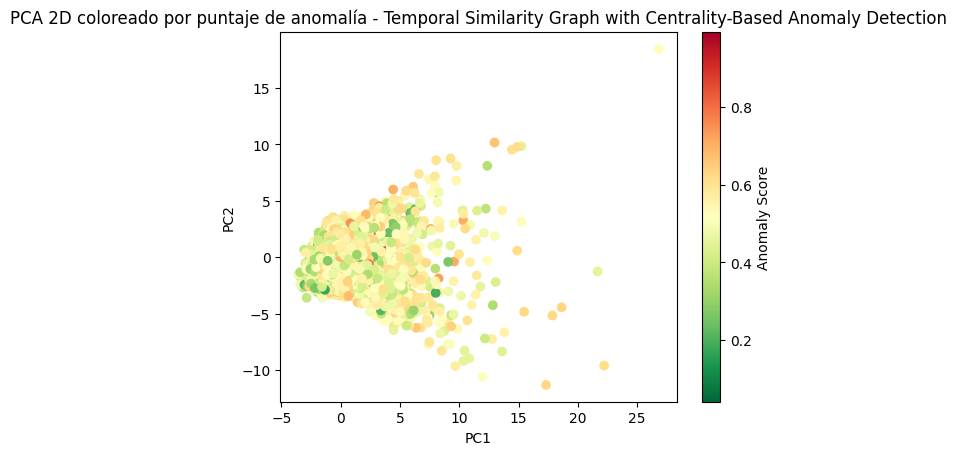

In [25]:
plot_pca_score(
    df=df_scored,
    features=features,
    score_col="anomaly_score_graph",
    title="PCA 2D coloreado por puntaje de anomalía - Temporal Similarity Graph with Centrality-Based Anomaly Detection"
)

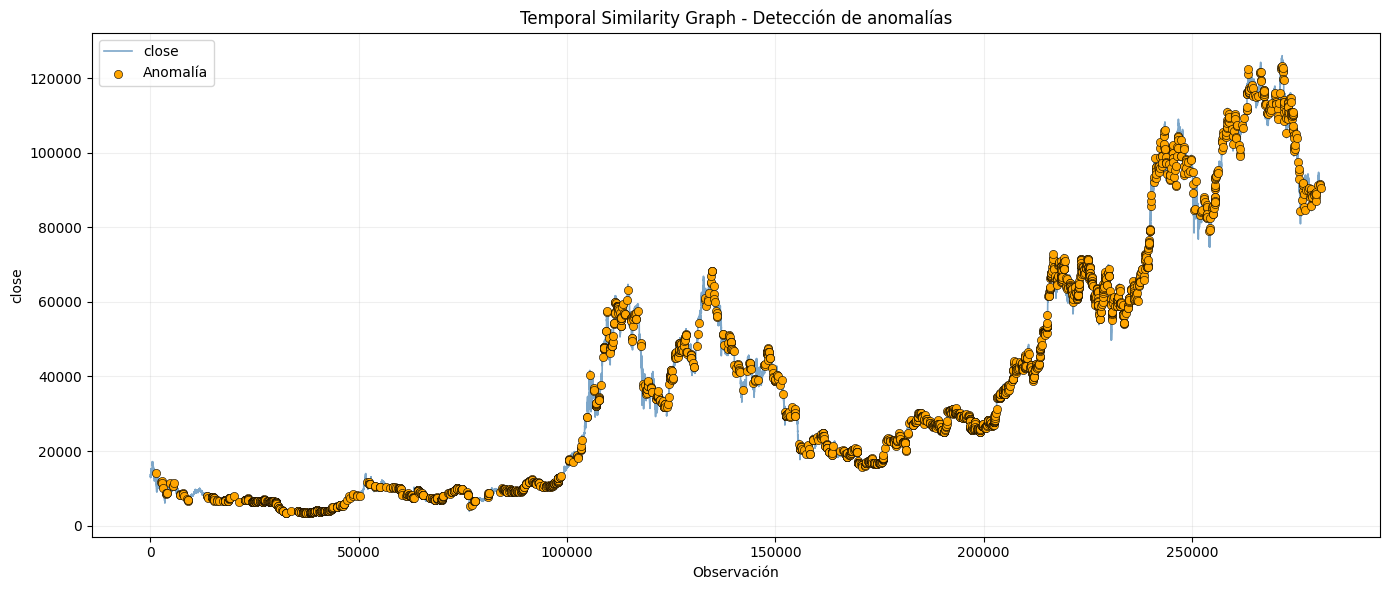

In [29]:
plot_close_anomalies(
    df_scored,
    anomaly_col="is_anomaly_graph",
    title="Temporal Similarity Graph - Detección de anomalías",
    anomaly_color="orange"
)

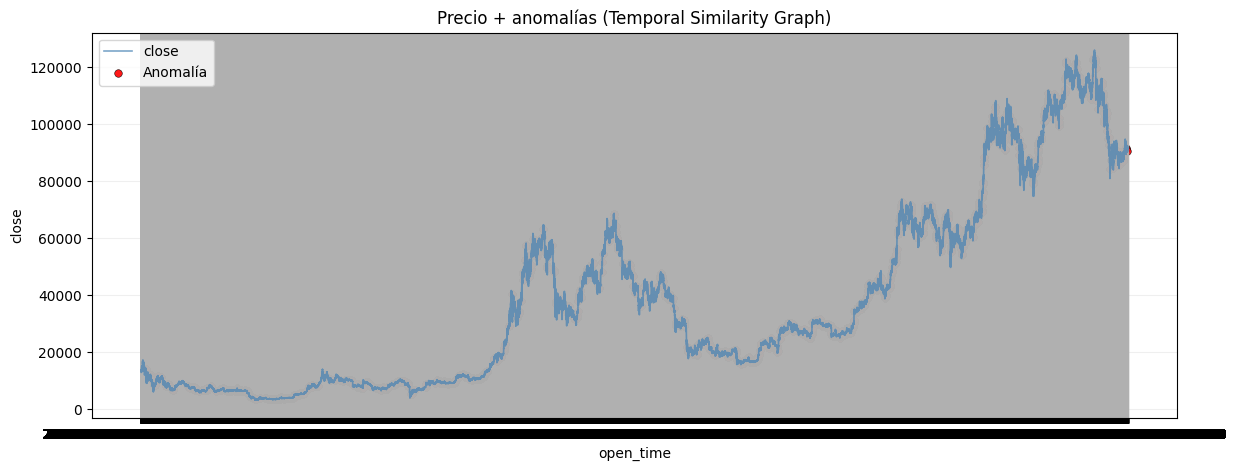

In [ ]:
# plot_price_with_anomalies(
#     df_scored,
#     anomaly_col="is_anomaly_graph",
#     time_col="open_time",
#     price_col="close",
#     title="Precio + anomalías (Temporal Similarity Graph)"
# )

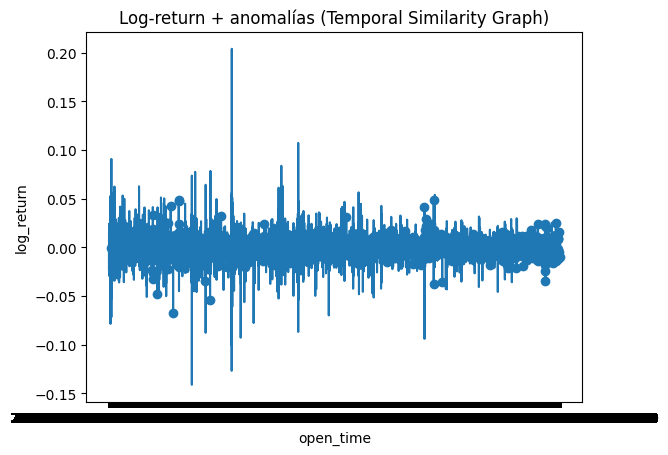

In [25]:
plot_feature_with_anomalies(
    df_scored,
    feature_col="log_return",
    anomaly_col="is_anomaly_graph",
    time_col="open_time",
    title="Log-return + anomalías (Temporal Similarity Graph)"
)

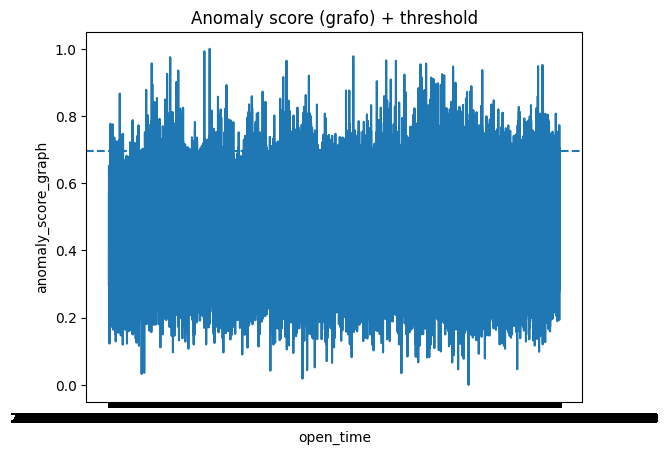

0.6946831772724861

In [26]:
thr_graph = plot_score_with_threshold(
    df_scored,
    score_col="anomaly_score_graph",
    time_col="open_time",
    contamination=0.01,
    title="Anomaly score (grafo) + threshold"
)
thr_graph

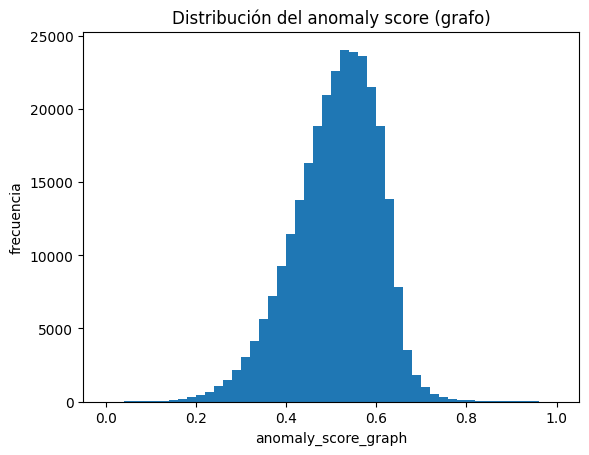

In [27]:
plot_score_hist(df_scored, score_col="anomaly_score_graph", title="Distribución del anomaly score (grafo)")

C:\Users\cecil\AppData\Local\Temp\ipykernel_20952\444105952.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal_vals, anom_vals], labels=["Normal", "Anómalo"])


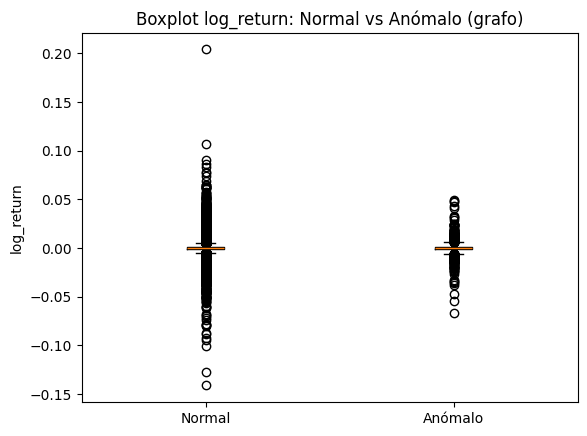

In [29]:
plot_box_normal_vs_anomaly(
    df_scored,
    feature_col="log_return",
    anomaly_col="is_anomaly_graph",
    title="Boxplot log_return: Normal vs Anómalo (grafo)"
)

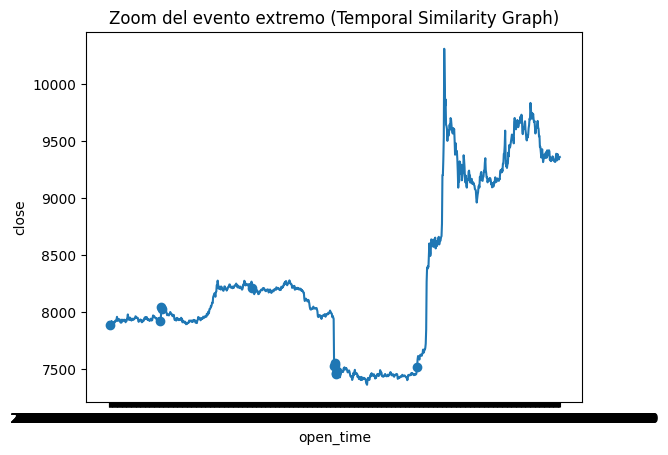

63025

In [30]:
top_idx = plot_zoom_top_event(
    df_scored,
    score_col="anomaly_score_graph",
    anomaly_col="is_anomaly_graph",
    time_col="open_time",
    price_col="close",
    window_points=500,
    title="Zoom del evento extremo (Temporal Similarity Graph)"
)
top_idx